In [2]:
#environment and file check
import sys, os, platform, hashlib, subprocess
from pathlib import Path
import numpy as np, pandas as pd, pyarrow, matplotlib

ROOT = Path("/projects/ancz7294/yjmob")
RAW  = ROOT / "data" / "raw"
for d in ["data/processed", "figures", "logs", "code"]:
    (ROOT / d).mkdir(parents=True, exist_ok=True)

print("python", sys.version.split()[0], "| exe", sys.executable)
print("numpy", np.__version__, "| pandas", pd.__version__,
      "| pyarrow", pyarrow.__version__, "| matplotlib", matplotlib.__version__)
print("node", platform.node(), "| cpus", os.cpu_count(),
      "| SLURM_CPUS_ON_NODE", os.environ.get("SLURM_CPUS_ON_NODE"),
      "| SLURM_MEM_PER_CPU", os.environ.get("SLURM_MEM_PER_CPU"),
      "| SLURM_MEM_PER_NODE", os.environ.get("SLURM_MEM_PER_NODE"),
      "| partition", os.environ.get("SLURM_JOB_PARTITION"))
print(subprocess.run(["df", "-h", str(ROOT)], capture_output=True, text=True).stdout)

expected = {
    "yjmob100k-dataset2.csv.gz":        "ec769fafa7a746caa3d48d2844b9735c",
    "cell_POIcat.csv.gz":               "93af4bb0b417cd20e95fdc1d8f7b459f",
    "POI_datacategories.csv":           "fd024e10c1d1dd91356d010413ace390",
    "foursquare/dataset_tsmc2014.zip":  "a9534dc06f0495b36f216017d2f47701",
}
def md5(p, chunk=1 << 22):
    h = hashlib.md5()
    with open(p, "rb") as f:
        for b in iter(lambda: f.read(chunk), b""):
            h.update(b)
    return h.hexdigest()

for rel, want in expected.items():
    p = RAW / rel
    if not p.exists():
        print(f"MISSING  {rel}"); continue
    got = md5(p)
    print(f"{'OK ' if got == want else 'BAD'} {rel:35s} {p.stat().st_size:>12,} bytes  md5 {got}")

python 3.11.13 | exe /projects/ancz7294/software/uv/envs/yjmob/bin/python
numpy 2.2.6 | pandas 2.3.3 | pyarrow 21.0.0 | matplotlib 3.10.6
node c3cpu-c15-u1-3 | cpus 64 | SLURM_CPUS_ON_NODE 8 | SLURM_MEM_PER_CPU 3840 | SLURM_MEM_PER_NODE None | partition acpu
Filesystem                                           Size  Used Avail Use% Mounted on
isilon1-data.rc.int.colorado.edu:/ifs/curc/projects  250G   65G  186G  26% /projects

OK  yjmob100k-dataset2.csv.gz            111,175,823 bytes  md5 ec769fafa7a746caa3d48d2844b9735c
OK  cell_POIcat.csv.gz                       626,648 bytes  md5 93af4bb0b417cd20e95fdc1d8f7b459f
OK  POI_datacategories.csv                     1,151 bytes  md5 fd024e10c1d1dd91356d010413ace390
OK  foursquare/dataset_tsmc2014.zip       25,546,284 bytes  md5 a9534dc06f0495b36f216017d2f47701


In [3]:
# loading YJMob dataset2 (full) and first look
import time
t0 = time.time()
yj = pd.read_csv(RAW / "yjmob100k-dataset2.csv.gz", engine="pyarrow",
                 dtype={"uid": "int32", "d": "int16", "t": "int16", "x": "int16", "y": "int16"})
print(f"loaded in {time.time()-t0:.1f} s")
print("shape", yj.shape, "| memory", f"{yj.memory_usage(deep=True).sum()/1e9:.2f} GB")
print(yj.dtypes.to_string()); print()
display(yj.head(10))
print("nulls per column:", yj.isna().sum().to_dict())
summ = pd.DataFrame({"min": yj.min(), "max": yj.max(), "nunique": yj.nunique()})
print(summ.to_string())
print("\nexact duplicate rows:", yj.duplicated().sum())
print("duplicate (uid,d,t) keys:", yj.duplicated(["uid","d","t"]).sum())
key = yj.uid.astype("int64")*10000 + yj.d.astype("int64")*100 + yj.t
print("file already sorted by uid,d,t:", key.is_monotonic_increasing)

loaded in 2.6 s
shape (29389749, 5) | memory 0.35 GB
uid    int32
d      int16
t      int16
x      int16
y      int16



,uid,d,t,x,y
0,0,0,0,163,60
1,0,0,1,163,60
2,0,0,2,163,61
3,0,0,5,163,60
4,0,0,8,163,61
5,0,0,9,163,60
6,0,0,11,163,60
7,0,0,12,163,61
8,0,0,13,163,60
9,0,0,14,163,61


nulls per column: {'uid': 0, 'd': 0, 't': 0, 'x': 0, 'y': 0}
     min    max  nunique
uid    0  24999    25000
d      0     74       75
t      0     47       48
x      1    200      200
y      1    200      200

exact duplicate rows: 0
duplicate (uid,d,t) keys: 0
file already sorted by uid,d,t: True


In [4]:
# structure of observaations and coverage
N_PEOPLE, N_DAYS, N_SLOTS = 25000, 75, 48
total_slots = N_PEOPLE * N_DAYS * N_SLOTS
print(f"overall coverage: {len(yj)/total_slots:.3%} of {total_slots:,} person-slots")

per_person = yj.groupby("uid").size()
print("\nrows per person:", per_person.describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).round(0).to_dict())
days_per_person = yj.groupby("uid")["d"].nunique()
print("days with >=1 obs per person:", days_per_person.describe(percentiles=[.05,.5,.95]).round(1).to_dict())

per_day = yj.groupby("d").size() / (N_PEOPLE * N_SLOTS)
print("\ncoverage by day (share of person-slots observed):")
print(per_day.round(3).to_string())
for lo, hi in [(0,44),(45,59),(60,66),(67,74)]:
    print(f"days {lo}-{hi}: coverage {per_day.loc[lo:hi].mean():.3%}, people seen {yj.loc[yj.d.between(lo,hi),'uid'].nunique():,}")

per_slot = yj.groupby("t").size() / (N_PEOPLE * N_DAYS)
print("\ncoverage by half-hour slot:"); print(per_slot.round(3).to_string())

per_phase = yj.groupby(yj.d % 7).size()
print("\nrows by weekly phase (d mod 7):"); print(per_phase.to_string())

print("\noccupied cells:", yj.groupby(["x","y"]).ngroups, "of 40,000")

overall coverage: 32.655% of 90,000,000 person-slots

rows per person: {'count': 25000.0, 'mean': 1176.0, 'std': 369.0, 'min': 571.0, '1%': 630.0, '5%': 709.0, '25%': 906.0, '50%': 1106.0, '75%': 1366.0, '95%': 1901.0, '99%': 2351.0, 'max': 3293.0}
days with >=1 obs per person: {'count': 25000.0, 'mean': 71.0, 'std': 6.5, 'min': 28.0, '5%': 56.0, '50%': 74.0, '95%': 75.0, 'max': 75.0}

coverage by day (share of person-slots observed):
d
0     0.278
1     0.293
2     0.347
3     0.347
4     0.355
5     0.362
6     0.311
7     0.276
8     0.300
9     0.360
10    0.360
11    0.360
12    0.365
13    0.321
14    0.281
15    0.361
16    0.364
17    0.360
18    0.359
19    0.367
20    0.317
21    0.279
22    0.353
23    0.357
24    0.359
25    0.363
26    0.375
27    0.226
28    0.293
29    0.307
30    0.365
31    0.364
32    0.363
33    0.371
34    0.317
35    0.288
36    0.346
37    0.297
38    0.362
39    0.359
40    0.361
41    0.312
42    0.277
43    0.348
44    0.348
45    0.345
46    0

## First look: the data are clean and the week is visible

The full table loads in under 3 seconds with pyarrow: 29,389,749 rows, 25,000 people, 75 days, 48 half-hour slots, a 200 x 200 grid of 500 m cells. No nulls, no duplicate rows, no duplicate (uid, d, t) keys, everything within the documented ranges, and the file is already sorted by person and time.

Only 32.7% of all person-slots are observed. Coverage follows a daily curve (12-13% overnight, peak at noon) and a clear 7-day rhythm: days with d mod 7 in {0, 6} have far fewer observations, so those two phases behave like a weekend even though the dataset never names weekdays. Day 27 is an odd low on a weekday phase (possible holiday or logging gap); it stays in the data and is flagged for the EDA.

The emergency shows up in the observation rate itself: about 33% coverage on days 0-59 versus 30.4% on days 60-66 and 29.5% on days 67-74. Being recorded is therefore an outcome to report, not just a nuisance. Everyone has at least 571 rows, but 389 people have no observation at all in days 45-59, so eligibility will have to be checked per window.

Decisions so far: keep the protocol windows (0-44 fit, 45-59 validation, 60-66 feedback, 67-74 target), treat phases {0, 6} as weekend-like, no filtering yet.

In [5]:
# adjacent observations, gaps and step sizes (jitter hypothesis)
same = yj.uid.values[1:] == yj.uid.values[:-1]
gap  = (yj.d.values[1:].astype("int32") - yj.d.values[:-1]) * 48 + (yj.t.values[1:].astype("int32") - yj.t.values[:-1])
dx   = yj.x.values[1:].astype("int32") - yj.x.values[:-1]
dy   = yj.y.values[1:].astype("int32") - yj.y.values[:-1]
cheb = np.maximum(np.abs(dx), np.abs(dy))          # step in cells (Chebyshev)
eucl = np.hypot(dx, dy) * 0.5                        # km, cell-centre to cell-centre

pairs = pd.DataFrame({"uid": yj.uid.values[:-1][same], "gap": gap[same], "cheb": cheb[same], "km": eucl[same],
                      "d": yj.d.values[:-1][same], "t": yj.t.values[:-1][same]})
print("consecutive same-person pairs:", f"{len(pairs):,}")
print("gap in slots:", pairs.gap.value_counts(normalize=True).sort_index().head(8).round(4).to_dict(), "| gap>48 slots:", f"{(pairs.gap>48).mean():.3%}")

adj = pairs[pairs.gap == 1]
print(f"\nadjacent pairs (exactly 30 min apart): {len(adj):,} = {len(adj)/len(pairs):.1%} of pairs")
print("changed cell share:", f"{(adj.cheb>0).mean():.3%}")
print("step size in cells (Chebyshev), share:")
print(adj.cheb.value_counts(normalize=True).sort_index().head(12).round(4).to_string())
print("step > 20 cells (10 km):", f"{(adj.cheb>20).sum():,}", "| step > 100 cells (50 km):", f"{(adj.cheb>100).sum():,}", "| max cells:", adj.cheb.max())

# flicker: A -> B -> A with B one cell away, within adjacent slots
x, y, u = yj.x.values.astype("int32"), yj.y.values.astype("int32"), yj.uid.values
g = np.r_[gap, 0]
trip = (u[2:] == u[:-2]) & (g[:-2] == 1) & (g[1:-1] == 1)
back = (x[2:] == x[:-2]) & (y[2:] == y[:-2]) & ((x[1:-1] != x[:-2]) | (y[1:-1] != y[:-2]))
one  = np.maximum(np.abs(x[1:-1]-x[:-2]), np.abs(y[1:-1]-y[:-2])) == 1
print(f"\nA->B->A triples among adjacent triples: {(trip&back).sum():,} of {trip.sum():,} = {(trip&back).sum()/trip.sum():.2%}; with B one cell away: {(trip&back&one).sum():,}")
print("share of one-cell steps that immediately return:", f"{(trip&back&one).sum() / ((trip)&(one)).sum():.2%}")

consecutive same-person pairs: 29,364,749
gap in slots: {1: 0.6989, 2: 0.1054, 3: 0.0479, 4: 0.029, 5: 0.0178, 6: 0.0127, 7: 0.0095, 8: 0.0075} | gap>48 slots: 0.201%

adjacent pairs (exactly 30 min apart): 20,522,060 = 69.9% of pairs
changed cell share: 81.080%
step size in cells (Chebyshev), share:
cheb
0     0.1892
1     0.2582
2     0.0998
3     0.0623
4     0.0466
5     0.0390
6     0.0328
7     0.0274
8     0.0241
9     0.0208
10    0.0184
11    0.0168
step > 20 cells (10 km): 1,564,424 | step > 100 cells (50 km): 11,415 | max cells: 193

A->B->A triples among adjacent triples: 1,471,363 of 14,693,539 = 10.01%; with B one cell away: 1,020,789
share of one-cell steps that immediately return: 27.62%


## Most "movement" between neighbouring slots is boundary noise (hypothesis)

70% of consecutive records are exactly 30 minutes apart (20.5M adjacent pairs). Of those, 81% change cell, which is implausible for a population that mostly stays at home or work. A quarter of adjacent pairs are exactly one-cell moves, and 28% of those bounce straight back (A to B to A, 1.02M cases). The likely reason is that people near a 500 m cell boundary get logged in either cell. So the raw "changed cell" rate is inflated, and one-cell moves need separate treatment.

Hypothesis, not a filter: nothing is deleted. The analysis table will carry the step size in cells, the gap in slots, and a flicker flag for the one-cell A-B-A pattern, so that any later result can be checked with and without them. A literature check is needed before calling this an unreported artefact of YJMob100K dataset.

The long tail is also real: 7.6% of adjacent pairs cover more than 10 km in 30 minutes (trains), and 11,415 exceed 50 km (over 100 km/h). Those get a big_jump flag for sensitivity analysis; the threshold is chosen after looking at the tail below.

In [6]:
#tail of step sizes, where big jumps live, and return rate by step size
tail = adj.cheb
for k in [20, 40, 60, 80, 100, 120, 150, 200]:
    print(f"  > {k:3d} cells ({k/2:5.0f} km): {(tail>k).sum():>9,}  {(tail>k).mean():.4%}")

big = adj[adj.cheb > 100]
print("\nbig jumps (>100 cells) by time slot of the first record (share):")
print(big.t.value_counts(normalize=True).sort_index().round(3).to_string())
print("\nbig jumps by day window:")
for lo, hi in [(0,44),(45,59),(60,66),(67,74)]:
    m = big.d.between(lo,hi); n = adj.d.between(lo,hi).sum()
    print(f"  days {lo}-{hi}: {m.sum():,} of {n:,} adjacent pairs = {m.sum()/n:.4%}")
print("\npeople with >=1 big jump:", big.uid.nunique(), "| top 10 people by count:", big.uid.value_counts().head(10).to_dict())

idx = np.flatnonzero(same & (gap == 1) & (cheb > 100)); nxt = idx + 1; ok = nxt < len(same)
print(f"share of big jumps followed immediately by another big jump: {(same[nxt[ok]] & (gap[nxt[ok]]==1) & (cheb[nxt[ok]]>100)).mean():.1%}")

# return rate (A->B->A within adjacent slots) by size of the first step
step1 = np.maximum(np.abs(x[1:-1]-x[:-2]), np.abs(y[1:-1]-y[:-2]))
print("\nA->B->A return rate by size of first step (adjacent triples only):")
for k in [1, 2, 3, 4, 5, 10, 20]:
    m = trip & (step1 == k)
    print(f"  step {k:2d} cells: n={m.sum():>9,}  return rate {(trip&back&(step1==k)).sum()/m.sum():.2%}")

  >  20 cells (   10 km): 1,564,424  7.6231%
  >  40 cells (   20 km):   382,121  1.8620%
  >  60 cells (   30 km):   107,708  0.5248%
  >  80 cells (   40 km):    34,102  0.1662%
  > 100 cells (   50 km):    11,415  0.0556%
  > 120 cells (   60 km):     4,179  0.0204%
  > 150 cells (   75 km):       549  0.0027%
  > 200 cells (  100 km):         0  0.0000%

big jumps (>100 cells) by time slot of the first record (share):
t
0     0.010
1     0.009
2     0.011
3     0.009
4     0.009
5     0.010
6     0.009
7     0.009
8     0.011
9     0.010
10    0.013
11    0.017
12    0.024
13    0.025
14    0.026
15    0.028
16    0.030
17    0.030
18    0.026
19    0.025
20    0.027
21    0.027
22    0.027
23    0.029
24    0.030
25    0.028
26    0.029
27    0.027
28    0.028
29    0.029
30    0.027
31    0.028
32    0.027
33    0.024
34    0.024
35    0.025
36    0.023
37    0.021
38    0.023
39    0.021
40    0.021
41    0.021
42    0.019
43    0.019
44    0.018
45    0.014
46    0.013
47    0.

The return test separates noise from trips: one-cell moves bounce back 27.6% of the time, two-cell moves 13.3%, and from five cells on the rate settles at a floor of 2.5-4%, which is what real short round trips look like. Roughly 0.9M of the 3.7M one-cell adjacent moves are therefore boundary noise. Two-cell moves carry a milder dose (people near a cell corner).

The long tail is smooth with no cliff and no step above 100 km, so there are no impossible teleports and any cut-off is a convention. Steps over 50 km in 30 minutes (11,415, over 100 km/h) happen in daytime, belong to 2,733 people, often come in pairs (27% are followed by another such step, i.e. long-distance commuters) and are slightly more frequent in the emergency. They get a big_jump flag for sensitivity analysis; nothing is removed.

In [7]:
#adjacent pairs per person per window (eligibility inputs)
win = pd.cut(adj.d, bins=[-1, 44, 59, 66, 74], labels=["fit_0_44", "val_45_59", "fb_60_66", "tgt_67_74"])
ppw = adj.groupby([adj.uid, win], observed=False).size().unstack(fill_value=0)
print("adjacent pairs per person per window:")
print(ppw.describe(percentiles=[.01,.05,.1,.25,.5]).round(0).to_string())
print("\npeople with 0 adjacent pairs per window:", (ppw == 0).sum().to_dict())
print("\nshare of people meeting a minimum of k adjacent pairs in EVERY window:")
for k in [5, 10, 20, 30, 50]:
    print(f"  k={k:3d}: {(ppw >= k).all(axis=1).mean():.1%}  ({(ppw >= k).all(axis=1).sum():,} people)")
print("\nsame, requiring k in val_45_59 and tgt_67_74 only:")
for k in [5, 10, 20, 30, 50]:
    m = (ppw[["val_45_59","tgt_67_74"]] >= k).all(axis=1)
    print(f"  k={k:3d}: {m.mean():.1%}  ({m.sum():,} people)")
# what kind of people would a k=20 rule drop? compare coverage and radius
prof = yj.groupby("uid").agg(rows=("d","size"), days=("d","nunique"), ncells=("x", lambda s: 0))
prof["ncells"] = yj.groupby("uid").apply(lambda g: g[["x","y"]].drop_duplicates().shape[0], include_groups=False)
keep = (ppw >= 20).all(axis=1)
print("\nk=20 rule, kept vs dropped (median rows, days, distinct cells):")
print(prof.groupby(keep).median().round(0).to_string())

adjacent pairs per person per window:
d      fit_0_44  val_45_59  fb_60_66  tgt_67_74
count   25000.0    25000.0   25000.0    25000.0
mean      514.0      170.0      65.0       71.0
std       236.0       88.0      33.0       37.0
min         0.0        0.0       0.0        0.0
1%        172.0        0.0      20.0       22.0
5%        227.0       53.0      29.0       32.0
10%       263.0       75.0      33.0       37.0
25%       342.0      109.0      43.0       47.0
50%       464.0      157.0      57.0       62.0
max      1971.0      651.0     308.0      360.0

people with 0 adjacent pairs per window: {'fit_0_44': 1, 'val_45_59': 403, 'fb_60_66': 4, 'tgt_67_74': 28}

share of people meeting a minimum of k adjacent pairs in EVERY window:
  k=  5: 98.0%  (24,495 people)
  k= 10: 97.6%  (24,400 people)
  k= 20: 96.1%  (24,027 people)
  k= 30: 88.7%  (22,174 people)
  k= 50: 50.2%  (12,546 people)

same, requiring k in val_45_59 and tgt_67_74 only:
  k=  5: 98.0%  (24,509 people)
  k= 10: 9

## Who has enough data to be evaluated

Most people have hundreds of adjacent pairs in the fit window and about 60 in each emergency window, but 403 people have none at all in days 45-59: they vanish for the whole validation fortnight. A rule of at least 20 adjacent pairs in every window keeps 96.1% of people (24,027); 30 already costs 11%, 50 costs half. The people that a 20-pair rule drops are simply observed less (median 950 rows vs 1,112; 60 observed days vs 74; 165 distinct cells vs 202), not obviously different in behaviour. Provisional decision: 20 adjacent pairs per window.

In [8]:
# seeded development / evaluation split by person
SEED = 20260917
rng = np.random.default_rng(SEED)
uids = np.arange(N_PEOPLE)
dev_mask = np.zeros(N_PEOPLE, bool)
dev_mask[rng.choice(N_PEOPLE, size=int(0.7 * N_PEOPLE), replace=False)] = True
split = pd.Series(np.where(dev_mask, "dev", "eval"), index=uids, name="split")
print(split.value_counts().to_dict(), "| seed", SEED)

prof["big_jumps"] = big.uid.value_counts().reindex(prof.index, fill_value=0)
prof = prof.join(ppw).join(split)
print("\nmedians by split (should be close):")
print(prof.groupby("split").median(numeric_only=True).round(0).to_string())

elig = (ppw >= 20).all(axis=1)
print("\neligible (>=20 adjacent pairs in every window) by split:",
      elig.groupby(split).mean().round(3).to_dict(),
      "| counts", elig.groupby(split).sum().to_dict())
print("eligibility rule fixed on development people: k=20 keeps", f"{elig[split=='dev'].mean():.1%}", "of dev")

# persist the person table for later cells and the prep script
prof["eligible"] = elig
prof.to_parquet(ROOT / "data/processed/person_table.parquet")
print("\nsaved data/processed/person_table.parquet", prof.shape)
print(prof.head().to_string())

{'dev': 17500, 'eval': 7500} | seed 20260917

medians by split (should be close):
         rows  days  ncells  big_jumps  fit_0_44  val_45_59  fb_60_66  tgt_67_74
split                                                                           
dev    1103.0  74.0   201.0        0.0     463.0      156.0      57.0       62.0
eval   1111.0  74.0   200.0        0.0     467.0      158.0      56.0       62.0

eligible (>=20 adjacent pairs in every window) by split: {'dev': 0.963, 'eval': 0.957} | counts {'dev': 16853, 'eval': 7174}
eligibility rule fixed on development people: k=20 keeps 96.3% of dev

saved data/processed/person_table.parquet (25000, 10)
     rows  days  ncells  big_jumps  fit_0_44  val_45_59  fb_60_66  tgt_67_74 split  eligible
uid                                                                                         
0    1319    45     121          1       665          0       196        183  eval     False
1    1223    64     396          0       666         98       11

## Split and eligibility fixed

Seeded 70/30 split by person (seed 20260917): 17,500 development, 7,500 evaluation people. The two groups match on rows, observed days, distinct cells, big jumps and adjacent pairs per window. The eligibility rule (at least 20 adjacent pairs in every window) is now fixed on development people, where it keeps 96.3%; it keeps 95.7% of evaluation people. Saved as data/processed/person_table.parquet.

In [9]:
# POI (categories) table first look
poi = pd.read_csv(RAW / "cell_POIcat.csv.gz")
cats = pd.read_csv(RAW / "POI_datacategories.csv", header=None)
print("cell_POIcat shape", poi.shape); print(poi.dtypes.to_string()); display(poi.head())
print("nulls:", poi.isna().sum().to_dict())
print("\nPOI_datacategories shape", cats.shape); display(cats.head(10))

# figure out the layout: one row per cell with 85 columns, or long (cell, category, count)?
print("\ncolumns:", list(poi.columns)[:10], "...")
if "POI_count" in poi.columns or poi.shape[1] <= 6:
    print("long format; categories:", poi.iloc[:, 2].nunique(), "| cells:", poi.groupby(list(poi.columns[:2])).ngroups)
else:
    print("wide format; category columns:", poi.shape[1] - 2)

occ = yj[["x","y"]].drop_duplicates()
poi_cells = poi[["x","y"]].drop_duplicates() if {"x","y"} <= set(poi.columns) else None
if poi_cells is not None:
    m = occ.merge(poi_cells, how="left", indicator=True)
    print(f"\noccupied cells: {len(occ):,} | cells with POI rows: {len(poi_cells):,} | occupied cells with POI info: {(m._merge=='both').sum():,}")
    obs_in_poi = yj.merge(poi_cells.assign(has_poi=True), how="left").has_poi.fillna(False).mean()
    print(f"share of observations falling in a cell with POI info: {obs_in_poi:.1%}")

cell_POIcat shape (221159, 4)
x              int64
y              int64
POIcategory    int64
POI_count      int64


,x,y,POIcategory,POI_count
0,1,1,48,4
1,1,1,58,1
2,1,1,59,1
3,1,1,69,2
4,1,1,73,1


nulls: {'x': 0, 'y': 0, 'POIcategory': 0, 'POI_count': 0}

POI_datacategories shape (85, 1)


,0
0,Food
1,Shopping
2,Entertainment
3,Japanese restaurant
4,Western restaurant
5,Eat all you can restaurant
6,Chinese restaurant
7,Indian restaurant
8,Ramen restaurant
9,Curry restaurant



columns: ['x', 'y', 'POIcategory', 'POI_count'] ...
long format; categories: 85 | cells: 20146

occupied cells: 30,277 | cells with POI rows: 20,146 | occupied cells with POI info: 19,998
share of observations falling in a cell with POI info: 97.2%


/tmp/ipykernel_4038165/2438270553.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  obs_in_poi = yj.merge(poi_cells.assign(has_poi=True), how="left").has_poi.fillna(False).mean()


## The POI table

221,159 rows in long form: cell (x, y), anonymous category ID (85), count. 20,146 cells have POI information; they cover 19,998 of the 30,277 occupied cells and 97.2% of all observations. The remaining occupied cells (2.8% of observations) have no POI row and are treated as zero-POI cells with a has_poi flag, not dropped. The 85 category names ship as a plain list; the ID-to-name mapping is withheld by the authors, so the names are never attached as if they were a feature.

In [10]:
#  wide cell x category table - better look:DDD
print("POIcategory range:", poi.POIcategory.min(), poi.POIcategory.max(), "| POI_count range:", poi.POI_count.min(), poi.POI_count.max())
wide = poi.pivot_table(index=["x","y"], columns="POIcategory", values="POI_count", fill_value=0, aggfunc="sum")
wide.columns = [f"cat{c}" for c in wide.columns]
print("wide shape", wide.shape, "| density (nonzero share)", f"{(wide.values>0).mean():.1%}")
tot = wide.sum(axis=1)
print("POIs per cell:", tot.describe(percentiles=[.5,.9,.99]).round(0).to_dict())
cat_tot = wide.sum().sort_values(ascending=False)
print("\ntop 10 categories by total count (IDs only):"); print(cat_tot.head(10).to_string())
print("bottom 5:"); print(cat_tot.tail(5).to_string())
print("\ncategories present per cell:", (wide>0).sum(axis=1).describe(percentiles=[.5,.9]).round(1).to_dict())

# attach to all occupied cells, zeros where no POI row
cells = occ.set_index(["x","y"]).join(wide, how="left")
cells["has_poi"] = cells["cat1"].notna() if "cat1" in cells else cells.iloc[:,0].notna()
cells = cells.fillna(0).astype({c: "int32" for c in wide.columns})
cells["poi_total"] = cells[wide.columns].sum(axis=1)
cells.to_parquet(ROOT / "data/processed/cell_table.parquet")
print("\nsaved data/processed/cell_table.parquet", cells.shape, "| has_poi share", f"{cells.has_poi.mean():.1%}")

POIcategory range: 1 85 | POI_count range: 1 735
wide shape (20146, 85) | density (nonzero share) 12.9%
POIs per cell: {'count': 20146.0, 'mean': 25.0, 'std': 56.0, 'min': 1.0, '50%': 9.0, '90%': 61.0, '99%': 194.0, 'max': 2479.0}

top 10 categories by total count (IDs only):
cat59    42806
cat81    39226
cat48    25758
cat69    25716
cat79    20547
cat60    18528
cat76    16783
cat74    16199
cat62    16023
cat4     13853
bottom 5:
cat25    24
cat30     4
cat24     2
cat28     2
cat29     1

categories present per cell: {'count': 20146.0, 'mean': 11.0, 'std': 11.2, 'min': 1.0, '50%': 7.0, '90%': 28.0, 'max': 77.0}

saved data/processed/cell_table.parquet (30277, 87) | has_poi share 66.1%


The wide table is 20,146 cells x 85 categories, 12.9% nonzero. A median cell has 9 POIs in 7 categories; the densest has 2,479. Category totals are very uneven (42,806 for the largest ID, 1 for the smallest; four IDs have under 25 POIs city-wide), so later PCA/NMF will rest on a few dozen categories. Saved as data/processed/cell_table.parquet with a has_poi flag and a poi_total column (30,277 occupied cells, 66% with POI info).

In [11]:
# build and save (all rows kept, flags added)
t0 = time.time()
an = yj.copy()
an["phase"]   = (an.d % 7).astype("int8")
an["weekend"] = an.phase.isin([0, 6])
an["window"]  = pd.cut(an.d, bins=[-1, 44, 59, 66, 74], labels=["fit","val","fb","tgt"]).astype("category")
an["slot"]    = (an.d.astype("int32") * 48 + an.t).astype("int32")          # absolute half-hour index

prev_same = np.r_[False, same]
an["gap_prev"]  = np.where(prev_same, np.r_[0, gap], -1).astype("int16")    # -1 = first record of a person
an["step_prev"] = np.where(prev_same, np.r_[0, cheb], -1).astype("int16")   # cells, Chebyshev
an["adjacent"]  = an.gap_prev == 1
an["big_jump"]  = an.adjacent & (an.step_prev > 100)

# flicker: this record is B in an A->B->A one-cell pattern with adjacent slots on both sides
fl = np.zeros(len(an), bool); fl[1:-1] = trip & back & one
an["flicker_mid"] = fl
an = an.join(prof[["split","eligible"]], on="uid")
an["split"] = an.split.astype("category")

print(f"built in {time.time()-t0:.1f} s | shape {an.shape} | memory {an.memory_usage(deep=True).sum()/1e9:.2f} GB")
print(an.dtypes.to_string())
print("\nflag shares:", {c: f"{an[c].mean():.3%}" for c in ["adjacent","big_jump","flicker_mid","weekend","eligible"]})
print("window rows:", an.window.value_counts().sort_index().to_dict())
an.to_parquet(ROOT / "data/processed/yjmob_analysis.parquet", index=False)
print("saved data/processed/yjmob_analysis.parquet", f"{(ROOT/'data/processed/yjmob_analysis.parquet').stat().st_size/1e6:.0f} MB")
display(an[an.uid == 0].head(8))

built in 3.3 s | shape (29389749, 16) | memory 0.82 GB
uid               int32
d                 int16
t                 int16
x                 int16
y                 int16
phase              int8
weekend            bool
window         category
slot              int32
gap_prev          int16
step_prev         int16
adjacent           bool
big_jump           bool
flicker_mid        bool
split          category
eligible           bool

flag shares: {'adjacent': '69.827%', 'big_jump': '0.039%', 'flicker_mid': '3.473%', 'weekend': '25.453%', 'eligible': '96.641%'}
window rows: {'fit': 18042021, 'val': 5966409, 'fb': 2552665, 'tgt': 2828654}
saved data/processed/yjmob_analysis.parquet 161 MB


,uid,d,t,x,y,phase,weekend,window,slot,gap_prev,step_prev,adjacent,big_jump,flicker_mid,split,eligible
0,0,0,0,163,60,0,True,fit,0,-1,-1,False,False,False,eval,False
1,0,0,1,163,60,0,True,fit,1,1,0,True,False,False,eval,False
2,0,0,2,163,61,0,True,fit,2,1,1,True,False,False,eval,False
3,0,0,5,163,60,0,True,fit,5,3,1,False,False,False,eval,False
4,0,0,8,163,61,0,True,fit,8,3,1,False,False,False,eval,False
5,0,0,9,163,60,0,True,fit,9,1,1,True,False,False,eval,False
6,0,0,11,163,60,0,True,fit,11,2,0,False,False,False,eval,False
7,0,0,12,163,61,0,True,fit,12,1,1,True,False,True,eval,False


## YJMob analysis table

All 29,389,749 rows kept, with derived columns: weekly phase and weekend flag, window (fit/val/fb/tgt), absolute slot index, gap and step to the person's previous record, and the flags adjacent (69.8%), big_jump (0.04%), flicker_mid (3.5%, the middle record of a one-cell A-B-A pattern), plus split and eligible per person. Saved as data/processed/yjmob_analysis.parquet (161 MB). Cleaning here means documenting and flagging, not deleting: the raw data have no missing or malformed values, and the questionable records (boundary flicker, 50 km jumps) are hypotheses to test, not errors to erase. 

In [12]:
# NEw dataset! Foursquare Tokyo check-ins, first look
import zipfile
zf = zipfile.ZipFile(RAW / "foursquare/dataset_tsmc2014.zip")
print([ (i.filename, i.file_size) for i in zf.infolist() ])
tky_name = [n for n in zf.namelist() if "TKY" in n and n.endswith(".txt")][0]
cols = ["user_id","venue_id","venue_cat_id","venue_cat_name","lat","lon","tz_offset","utc_time"]
fs = pd.read_csv(zf.open(tky_name), sep="\t", header=None, names=cols, encoding="latin-1")
print("\nshape", fs.shape); print(fs.dtypes.to_string()); display(fs.head())
print("nulls:", fs.isna().sum().to_dict(), "| exact duplicate rows:", fs.duplicated().sum())
print("users", fs.user_id.nunique(), "| venues", fs.venue_id.nunique(),
      "| category ids", fs.venue_cat_id.nunique(), "| category names", fs.venue_cat_name.nunique())
print("tz_offset values:", fs.tz_offset.value_counts().head(5).to_dict())

fs["utc"] = pd.to_datetime(fs.utc_time, format="%a %b %d %H:%M:%S %z %Y", utc=True)
fs["local"] = fs.utc + pd.to_timedelta(fs.tz_offset, unit="m")
fs["local"] = fs.local.dt.tz_localize(None)
print("\nlocal time range:", fs.local.min(), "to", fs.local.max())
print("lat range", fs.lat.min(), fs.lat.max(), "| lon range", fs.lon.min(), fs.lon.max())
print("\ntop 10 category names:"); print(fs.venue_cat_name.value_counts(normalize=True).head(10).round(3).to_string())
print("\ncheck-ins per user:", fs.groupby("user_id").size().describe(percentiles=[.5,.9]).round(0).to_dict())

[('dataset_tsmc2014/', 0), ('dataset_tsmc2014/dataset_TSMC2014_NYC.txt', 31480163), ('dataset_tsmc2014/dataset_TSMC2014_readme.txt', 1408), ('dataset_tsmc2014/dataset_TSMC2014_TKY.txt', 79467384)]

shape (573703, 8)
user_id             int64
venue_id           object
venue_cat_id       object
venue_cat_name     object
lat               float64
lon               float64
tz_offset           int64
utc_time           object


,user_id,venue_id,venue_cat_id,venue_cat_name,lat,lon,tz_offset,utc_time
0,1541,4f0fd5a8e4b03856eeb6c8cb,4bf58dd8d48988d10c951735,Cosmetics Shop,35.705101,139.619590,540,Tue Apr 03 18:17:18 +0000 2012
1,868,4b7b884ff964a5207d662fe3,4bf58dd8d48988d1d1941735,Ramen / Noodle House,35.715581,139.800317,540,Tue Apr 03 18:22:04 +0000 2012
2,114,4c16fdda96040f477cc473a5,4d954b0ea243a5684a65b473,Convenience Store,35.714542,139.480065,540,Tue Apr 03 19:12:07 +0000 2012
3,868,4c178638c2dfc928651ea869,4bf58dd8d48988d118951735,Food & Drink Shop,35.725592,139.776633,540,Tue Apr 03 19:12:13 +0000 2012
4,1458,4f568309e4b071452e447afe,4f2a210c4b9023bd5841ed28,Housing Development,35.656083,139.734045,540,Tue Apr 03 19:18:23 +0000 2012


nulls: {'user_id': 0, 'venue_id': 0, 'venue_cat_id': 0, 'venue_cat_name': 0, 'lat': 0, 'lon': 0, 'tz_offset': 0, 'utc_time': 0} | exact duplicate rows: 577
users 2293 | venues 61858 | category ids 385 | category names 247
tz_offset values: {540: 573676, -480: 8, -300: 5, -240: 3, 60: 3}

local time range: 2012-04-04 03:17:18 to 2013-02-16 11:35:29
lat range 35.510184690694565 35.867150422391695 | lon range 139.4708776473999 139.91259321570396

top 10 category names:
venue_cat_name
Train Station            0.349
Subway                   0.073
Ramen /  Noodle House    0.030
Convenience Store        0.029
Japanese Restaurant      0.027
Bar                      0.026
Food & Drink Shop        0.024
Electronics Store        0.019
Mall                     0.019
Coffee Shop              0.016

check-ins per user: {'count': 2293.0, 'mean': 250.0, 'std': 222.0, 'min': 100.0, '50%': 173.0, '90%': 476.0, 'max': 2991.0}


## Foursquare Tokyo: a second, labelled source

573,703 check-ins by 2,293 users at 61,858 venues, April 2012 to February 2013. No nulls; 577 exact duplicate rows; 385 category IDs collapse to 247 names. 27 check-ins carry a non-JST offset although the venue is in Tokyo. Heavy imbalance: Train Station alone is 34.9% of check-ins, Subway 7.3%. Unlike YJMob these are voluntary, event-like records (median 173 per user over ten months), not a trace; their value is the real place-type label.

In [13]:
# Foursquare cleaning and derived fields
fs2 = fs.drop_duplicates().copy()
print("after dropping exact duplicates:", fs2.shape)
fs2["tz_flag"] = fs2.tz_offset != 540
fs2["local"] = (fs2.utc + pd.Timedelta(minutes=540)).dt.tz_localize(None)     # JST for all rows
fs2["venue_cat_name"] = fs2.venue_cat_name.str.replace(r"\s+", " ", regex=True).str.strip()
print("category names after whitespace fix:", fs2.venue_cat_name.nunique())

# 500 m grid on a local equirectangular projection, origin at the SW corner of the data
lat0, lon0 = fs2.lat.min(), fs2.lon.min()
km_per_deg_lat = 111.32
km_per_deg_lon = 111.32 * np.cos(np.deg2rad(fs2.lat.mean()))
fs2["cx"] = ((fs2.lon - lon0) * km_per_deg_lon / 0.5).astype("int16") + 1
fs2["cy"] = ((fs2.lat - lat0) * km_per_deg_lat / 0.5).astype("int16") + 1
print("grid extent: cx 1..", fs2.cx.max(), "| cy 1..", fs2.cy.max(), "| occupied cells", fs2.groupby(["cx","cy"]).ngroups)

fs2["hour"] = fs2.local.dt.hour.astype("int8")
fs2["weekday"] = fs2.local.dt.weekday.astype("int8")       # 0 = Monday
fs2["weekend"] = fs2.weekday >= 5
fs2["date"] = fs2.local.dt.date
fs2["month"] = fs2.local.dt.to_period("M").astype(str)
print("\ncheck-ins per month:"); print(fs2.month.value_counts().sort_index().to_string())
print("\nweekend share", f"{fs2.weekend.mean():.1%}", "| peak hour", fs2.hour.value_counts().idxmax())

# venues with more than one category id
vc = fs2.groupby("venue_id").venue_cat_name.nunique()
print("venues with >1 category name:", (vc > 1).sum())

keep = ["user_id","venue_id","venue_cat_id","venue_cat_name","lat","lon","local","tz_flag","cx","cy","hour","weekday","weekend","month"]
fs2 = fs2.sort_values(["user_id","local"]).reset_index(drop=True)[keep]
fs2.to_parquet(ROOT / "data/processed/foursquare_tky.parquet", index=False)
print("\nsaved data/processed/foursquare_tky.parquet", fs2.shape)

after dropping exact duplicates: (573126, 10)
category names after whitespace fix: 247
grid extent: cx 1.. 80 | cy 1.. 80 | occupied cells 3853

check-ins per month:
month
2012-04    80362
2012-05    93510
2012-06    63398
2012-07    64454
2012-08    28056
2012-09    10093
2012-10    38400
2012-11    54511
2012-12    61528
2013-01    52146
2013-02    26668

weekend share 31.3% | peak hour 18
venues with >1 category name: 511

saved data/processed/foursquare_tky.parquet (573126, 14)


Cleaning: 577 exact duplicates dropped (573,126 rows left), local time set to JST for every row with a tz_flag on the 27 exceptions, whitespace normalised in names (still 247), coordinates binned to a local 500 m grid (80 x 80, 3,853 occupied cells) so that Foursquare and YJMob share a resolution, plus hour, weekday, weekend and month. Check-ins per month reveal a collection gap in September 2012 (10k against 50-90k elsewhere); this is a data-collection artefact and any time-based split has to avoid it. Saved as data/processed/foursquare_tky.parquet.

In [14]:
# coarse place-type groups (rule-based, first pass)
import re
rules = [
    ("Transit",     r"station|subway|train|bus|airport|platform|ferry|taxi|rental car|light rail|tram|pier|travel"),
    ("Nightlife",   r"\bbar\b|pub|nightclub|night club|lounge|sake|brewery|beer|karaoke|speakeasy|hookah|whisky|wine bar|strip club"),
    ("Food",        r"restaurant|ramen|noodle|caf[eé]|coffee|bakery|diner|food|sushi|steak|burger|pizza|bbq|donut|dessert|ice cream|tea|snack|sandwich|soup|curry|dumpling|udon|soba|yakitori|tonkatsu|okonomiyaki|kaiseki|donburi|nabe|unagi|shabu|takoyaki|wagashi|bistro|eatery|gastropub|creperie|breakfast|fried|wings|taco|burrito|cupcake|juice|smoothie"),
    ("Shopping",    r"store|shop|mall|market|boutique|mart|outlet|bookstore|pharmacy|drugstore|dealership|arcade|thrift|salon|spa"),
    ("Work/Study",  r"office|building|school|university|college|coworking|conference|library|lab|student|classroom|campus|factory|tech startup|government|city hall|courthouse|embassy|bank|post office|medical|hospital|doctor|dentist|clinic"),
    ("Home",        r"home|residential|housing|apartment|dorm|neighborhood"),
    ("Outdoors",    r"park|garden|plaza|trail|beach|river|lake|field|bridge|scenic|mountain|hot spring|pool|gym|fitness|stadium|sports|golf|ski|skate|bowling|tennis|soccer|baseball|racetrack|zoo|aquarium|harbor|castle|road|intersection|rest area"),
    ("Culture",     r"theater|theatre|museum|movie|cinema|music venue|concert|art|gallery|temple|shrine|church|historic|monument|arena|convention|event|festival|performing|comedy|casino|hotel|hostel|resort|inn|ryokan|amusement"),
]
def group(name):
    n = name.lower()
    for g, pat in rules:
        if re.search(pat, n): return g
    return "Other"
cat_map = pd.Series({n: group(n) for n in fs2.venue_cat_name.unique()}, name="group")
fs2["group"] = fs2.venue_cat_name.map(cat_map)

print("check-in share by group:"); print(fs2.group.value_counts(normalize=True).round(3).to_string())
print("\nnames per group:"); print(cat_map.value_counts().to_string())
print("\nnames left in Other (by check-in count):")
oth = fs2[fs2.group=="Other"].venue_cat_name.value_counts()
print(oth.head(40).to_string())
print("\nspot check, 5 random names per group:")
for g in cat_map.unique():
    print(f"  {g:11s}", list(cat_map[cat_map==g].sample(min(5,(cat_map==g).sum()), random_state=1).index))

check-in share by group:
group
Transit       0.450
Food          0.181
Shopping      0.155
Work/Study    0.069
Outdoors      0.061
Culture       0.033
Nightlife     0.027
Other         0.017
Home          0.007

names per group:
group
Food          73
Shopping      47
Other         36
Work/Study    28
Outdoors      23
Culture       19
Transit       12
Nightlife      5
Home           4

names left in Other (by check-in count):
venue_cat_name
Other Great Outdoors           3294
General Entertainment          1248
Playground                     1089
Deli / Bodega                   952
Athletic & Sport                779
Other Nightlife                 477
Spiritual Center                347
Laundry Service                 292
Military Base                   265
Cemetery                        193
Moving Target                   160
Recycling Facility               92
Outdoors & Recreation            90
Hot Dog Joint                    88
Fair                             78
Design Studio  

In [15]:
#fix the grouping (word boundaries + explicit overrides)
rules = [(g, re.compile(p)) for g, p in [
    ("Transit",    r"\b(station|subway|train|bus|airport|platform|ferry|taxi|rental car|light rail|tram|pier|travel|bike rental)\b"),
    ("Nightlife",  r"\b(bar|pub|nightclub|night club|lounge|sake|brewery|beer|karaoke|speakeasy|hookah|whisky|wine bar|strip club|nightlife|winery|distillery)\b"),
    ("Food",       r"restaurant|ramen|noodle|caf[eé]|coffee|bakery|diner|\bfood\b|sushi|steak|burger|pizza|bbq|donut|dessert|ice cream|\btea\b|snack|sandwich|soup|curry|dumpling|udon|soba|yakitori|tonkatsu|okonomiyaki|kaiseki|donburi|nabe|unagi|shabu|takoyaki|wagashi|bistro|eatery|gastropub|creperie|breakfast|fried|wings|taco|burrito|cupcake|juice|smoothie|deli|bodega|hot dog|salad|joint"),
    ("Shopping/Services", r"\b(store|shop|mall|market|boutique|mart|outlet|bookstore|pharmacy|drugstore|dealership|arcade|thrift|salon|spa|laundry|car wash|recycling|storage|newsstand|pet service|animal shelter|financial|legal|design studio|professional)\b"),
    ("Work/Study", r"\b(office|building|school|university|college|coworking|conference|library|lab|student|classroom|campus|factory|tech startup|government|city hall|courthouse|embassy|bank|post office|medical|hospital|doctor|dentist|clinic|military)\b"),
    ("Home",       r"\b(home|residential|housing|apartment|dorm|neighborhood|sorority|fraternity)\b"),
    ("Outdoors",   r"\b(park|garden|plaza|trail|beach|river|lake|field|bridge|scenic|mountain|hot spring|pool|gym|fitness|stadium|sports?|golf|ski|skate|bowling|tennis|soccer|baseball|racetrack|zoo|aquarium|harbor|castle|road|intersection|rest area|outdoors|playground|athletic|campground)\b"),
    ("Culture",    r"\b(theater|theatre|museum|movie|cinema|music venue|concert|art|gallery|temple|shrine|church|mosque|synagogue|spiritual|historic|monument|arena|convention|event|festival|fair|performing|comedy|casino|hotel|hostel|resort|inn|ryokan|amusement|entertainment|planetarium|cemetery)\b"),
]]
overrides = {"Public Art": "Culture", "Event Space": "Culture", "Funeral Home": "Shopping/Services",
             "Garden Center": "Shopping/Services", "Pool Hall": "Culture", "Moving Target": "Other", "City": "Other"}
def group(name):
    if name in overrides: return overrides[name]
    n = name.lower()
    for g, pat in rules:
        if pat.search(n): return g
    return "Other"
cat_map = pd.Series({n: group(n) for n in fs2.venue_cat_name.unique()}, name="group")
fs2["group"] = fs2.venue_cat_name.map(cat_map)
print("check-in share by group:"); print(fs2.group.value_counts(normalize=True).round(3).to_string())
print("\nnames per group:", cat_map.value_counts().to_dict())
print("\nstill Other:", fs2[fs2.group=="Other"].venue_cat_name.value_counts().to_dict())
print("\nfull mapping, sorted by group (review):")
for g in sorted(cat_map.unique()):
    print(f"\n[{g}]", ", ".join(sorted(cat_map[cat_map==g].index)))
cat_map.rename_axis("venue_cat_name").reset_index().to_csv(ROOT / "data/processed/foursquare_category_groups.csv", index=False)
fs2.to_parquet(ROOT / "data/processed/foursquare_tky.parquet", index=False)
print("\nsaved mapping csv and updated parquet")

check-in share by group:
group
Transit              0.450
Food                 0.183
Shopping/Services    0.153
Work/Study           0.070
Outdoors             0.068
Culture              0.041
Nightlife            0.028
Home                 0.007
Other                0.002

names per group: {'Food': 78, 'Shopping/Services': 58, 'Culture': 29, 'Work/Study': 29, 'Outdoors': 25, 'Transit': 13, 'Nightlife': 7, 'Home': 5, 'Other': 3}

still Other: {'Parking': 774, 'Moving Target': 160, 'City': 7}

full mapping, sorted by group (review):

[Culture] Art Gallery, Art Museum, Arts & Entertainment, Casino, Cemetery, Church, Comedy Club, Concert Hall, Convention Center, Event Space, Fair, General Entertainment, Historic Site, History Museum, Hotel, Mosque, Movie Theater, Museum, Music Venue, Performing Arts Venue, Planetarium, Pool Hall, Public Art, Science Museum, Shrine, Spiritual Center, Synagogue, Temple, Theater

[Food] Afghan Restaurant, African Restaurant, American Restaurant, Arepa Restau

In [16]:
# final overrides and group names
overrides.update({
    "Residential Building (Apartment / Condo)": "Home", "Parking": "Transit",
    "Bagel Shop": "Food", "Fish & Chips Shop": "Food",
    "Internet Cafe": "Culture", "Gaming Cafe": "Culture",
})
rename = {"Culture": "Culture/Leisure", "Work/Study": "Work/Institutions"}
cat_map = pd.Series({n: rename.get(group(n), group(n)) for n in fs2.venue_cat_name.unique()}, name="group")
fs2["group"] = fs2.venue_cat_name.map(cat_map)
print(fs2.group.value_counts(normalize=True).round(3).to_string())
print("names per group:", cat_map.value_counts().to_dict())
cat_map.rename_axis("venue_cat_name").reset_index().sort_values(["group","venue_cat_name"]).to_csv(ROOT / "data/processed/foursquare_category_groups.csv", index=False)
fs2.to_parquet(ROOT / "data/processed/foursquare_tky.parquet", index=False)
print("saved")

group
Transit              0.451
Food                 0.182
Shopping/Services    0.153
Work/Institutions    0.069
Outdoors             0.068
Culture/Leisure      0.042
Nightlife            0.028
Home                 0.007
Other                0.000
names per group: {'Food': 78, 'Shopping/Services': 56, 'Culture/Leisure': 31, 'Work/Institutions': 28, 'Outdoors': 25, 'Transit': 14, 'Nightlife': 7, 'Home': 6, 'Other': 2}
saved


## Coarse place types

The 247 Foursquare names are folded into 8 groups plus a negligible Other (167 check-ins): Transit 45%, Food 18%, Shopping/Services 15%, Work/Institutions 7%, Outdoors 7%, Culture/Leisure 4%, Nightlife 3%, Home 1%. The grouping is rule-based (keyword patterns plus an explicit override list) and every assignment was reviewed by hand; the full mapping is saved as data/processed/foursquare_category_groups.csv so it can be audited and changed. The keyword rules were drafted with the help of an LLM (Claude) and then corrected manually; LLM-assisted labelling and taxonomy mapping is an accepted practice in recent NLP work, provided the output is checked and published, which is done here. The grouping is a modelling choice and will be revisited when the classifier is built.

saved f01_yjmob_coverage_by_day
saved f02_yjmob_coverage_by_hour
saved f03_yjmob_rows_per_person
saved f04_yjmob_step_sizes
saved f05_yjmob_flicker_return_rate
saved f06_yjmob_occupancy_map
saved f07_yjmob_poi_map
saved f08_yjmob_poi_categories
saved f09_yjmob_coverage_person_before_after


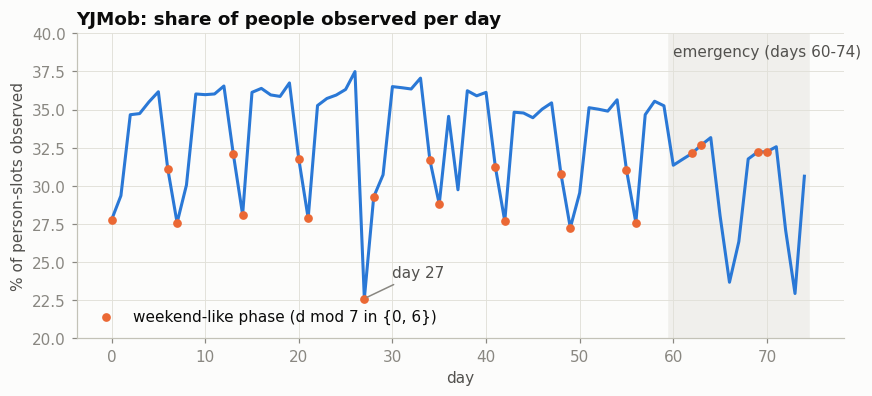

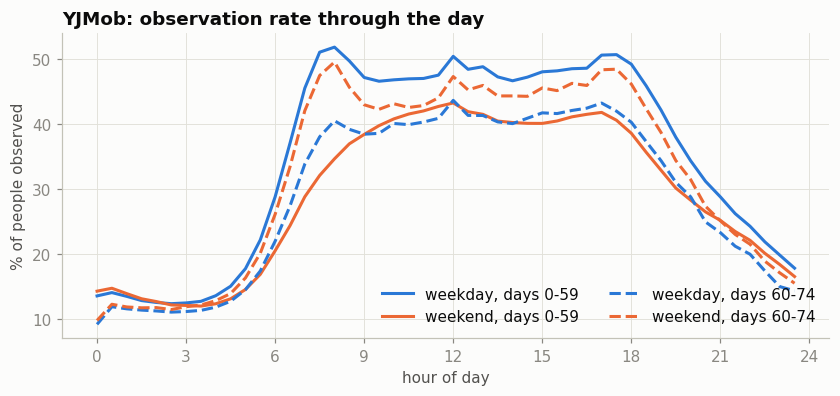

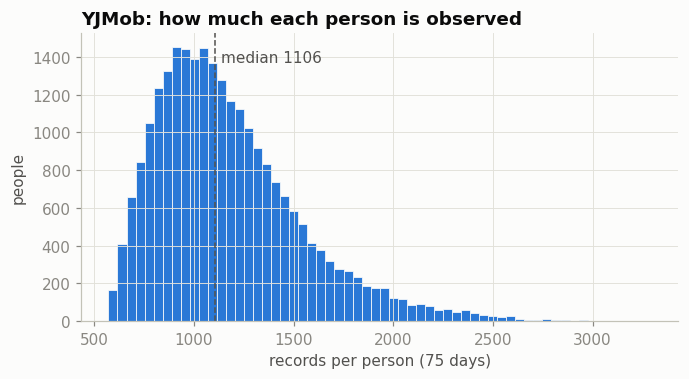

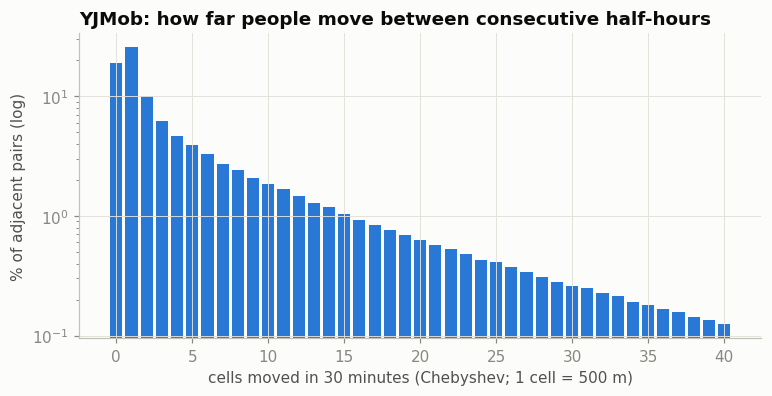

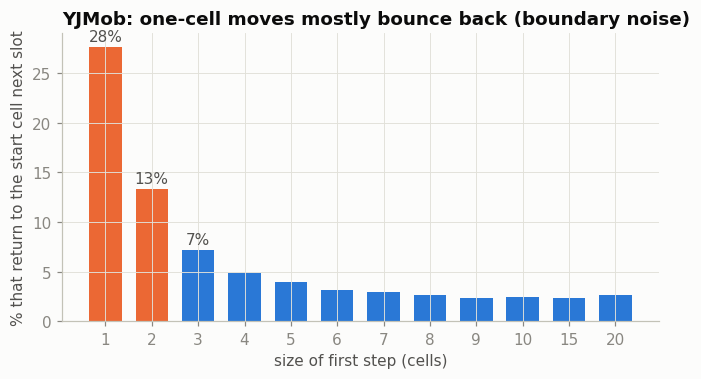

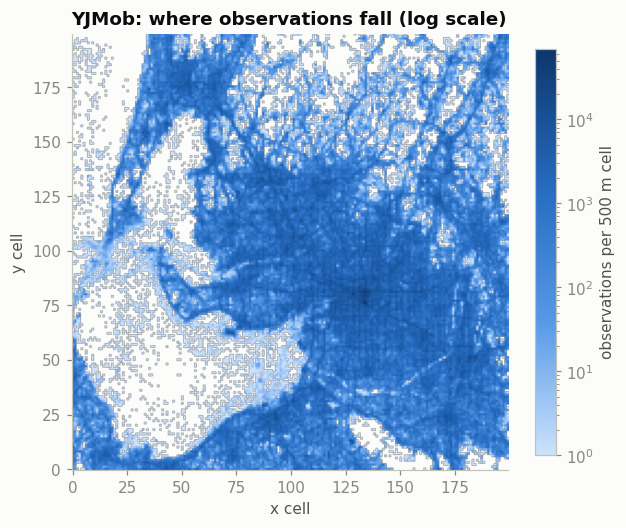

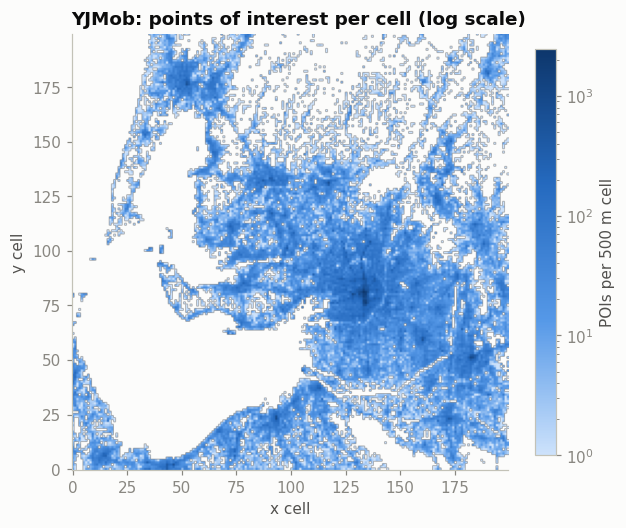

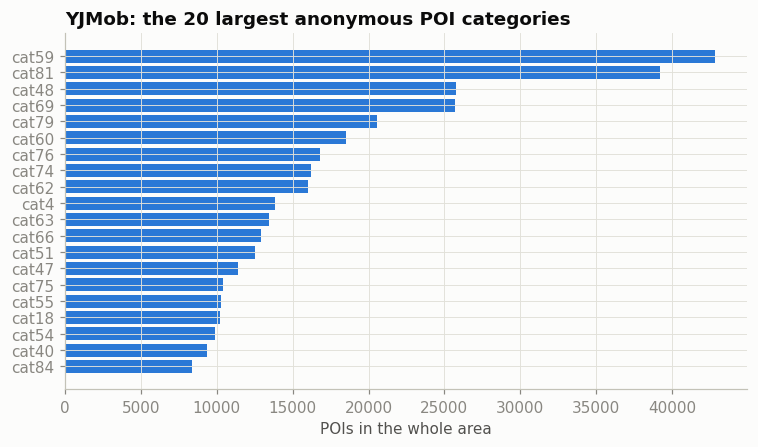

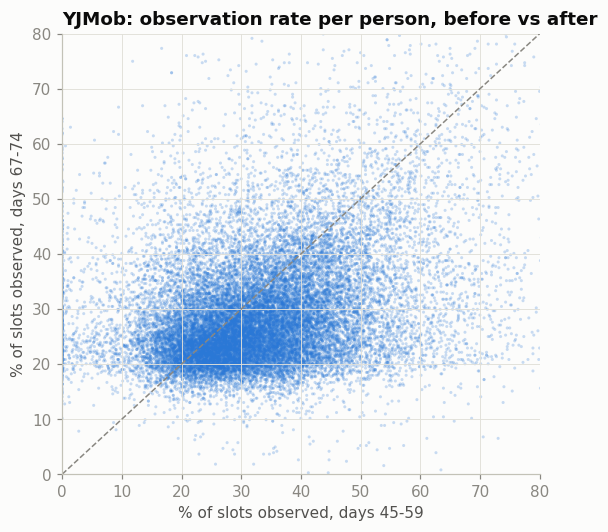

In [17]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
FIG = ROOT / "figures"
C = ["#2a78d6","#eb6834","#1baf7a","#eda100","#e87ba4","#008300","#4a3aa7","#e34948"]   # fixed categorical order
BLUES = LinearSegmentedColormap.from_list("blues", ["#cde2fb","#5598e7","#256abf","#0d366b"])
plt.rcParams.update({"figure.facecolor":"#fcfcfb","axes.facecolor":"#fcfcfb","axes.edgecolor":"#c3c2b7",
    "axes.grid":True,"grid.color":"#e1e0d9","grid.linewidth":0.6,"axes.spines.top":False,"axes.spines.right":False,
    "text.color":"#0b0b0b","axes.labelcolor":"#52514e","xtick.color":"#898781","ytick.color":"#898781",
    "font.family":"sans-serif","font.size":10,"axes.titlesize":12,"axes.titleweight":"bold","axes.titlelocation":"left",
    "figure.dpi":110,"savefig.dpi":150,"savefig.bbox":"tight"})
def save(fig, name): fig.savefig(FIG / f"{name}.png"); print("saved", name)

# F1 coverage by day, emergency shaded
fig, ax = plt.subplots(figsize=(9,3.6))
ax.axvspan(59.5, 74.5, color="#f0efec", zorder=0)
ax.plot(per_day.index, per_day.values*100, color=C[0], lw=2)
wk = per_day[(per_day.index % 7).isin([0,6])]
ax.scatter(wk.index, wk.values*100, color=C[1], s=22, zorder=3, label="weekend-like phase (d mod 7 in {0, 6})")
ax.annotate("day 27", (27, per_day[27]*100), xytext=(30, 24), arrowprops=dict(arrowstyle="-", color="#898781"), color="#52514e")
ax.text(60, 38.5, "emergency (days 60-74)", color="#52514e")
ax.set(xlabel="day", ylabel="% of person-slots observed", title="YJMob: share of people observed per day", ylim=(20,40)); ax.legend(frameon=False, loc="lower left")
save(fig, "f01_yjmob_coverage_by_day")

# F2 coverage by time of day, weekday vs weekend phases, normal vs emergency
fig, ax = plt.subplots(figsize=(9,3.6))
for (lab, mask, col, ls) in [("weekday, days 0-59", (~an.weekend)&(an.d<60), C[0], "-"), ("weekend, days 0-59", an.weekend&(an.d<60), C[1], "-"),
                             ("weekday, days 60-74", (~an.weekend)&(an.d>=60), C[0], "--"), ("weekend, days 60-74", an.weekend&(an.d>=60), C[1], "--")]:
    nd = an.loc[mask, "d"].nunique()
    s = an[mask].groupby("t").size() / (N_PEOPLE * nd) * 100
    ax.plot(s.index/2, s.values, color=col, ls=ls, lw=2, label=lab)
ax.set(xlabel="hour of day", ylabel="% of people observed", title="YJMob: observation rate through the day", xticks=range(0,25,3)); ax.legend(frameon=False, ncol=2)
save(fig, "f02_yjmob_coverage_by_hour")

# F3 rows per person
fig, ax = plt.subplots(figsize=(7,3.4))
ax.hist(per_person, bins=60, color=C[0], edgecolor="#fcfcfb", lw=0.5)
ax.axvline(per_person.median(), color="#52514e", lw=1, ls="--"); ax.text(per_person.median()+30, ax.get_ylim()[1]*0.9, f"median {per_person.median():.0f}", color="#52514e")
ax.set(xlabel="records per person (75 days)", ylabel="people", title="YJMob: how much each person is observed")
save(fig, "f03_yjmob_rows_per_person")

# F4 step size distribution for adjacent pairs (log y)
fig, ax = plt.subplots(figsize=(8,3.6))
vc = adj.cheb.value_counts().sort_index()
ax.bar(vc.index[:41], vc.values[:41]/len(adj)*100, color=C[0], width=0.8)
ax.set_yscale("log"); ax.set(xlabel="cells moved in 30 minutes (Chebyshev; 1 cell = 500 m)", ylabel="% of adjacent pairs (log)", title="YJMob: how far people move between consecutive half-hours")
save(fig, "f04_yjmob_step_sizes")

# F5 return rate by step size (the flicker test)
ks = list(range(1, 11)) + [15, 20]
rr = [((trip&back&(step1==k)).sum() / (trip&(step1==k)).sum()*100) for k in ks]
fig, ax = plt.subplots(figsize=(7,3.4))
ax.bar(range(len(ks)), rr, color=[C[1] if k<=2 else C[0] for k in ks], width=0.7)
ax.set_xticks(range(len(ks))); ax.set_xticklabels(ks)
for i, v in enumerate(rr[:3]): ax.text(i, v+0.6, f"{v:.0f}%", ha="center", color="#52514e")
ax.set(xlabel="size of first step (cells)", ylabel="% that return to the start cell next slot", title="YJMob: one-cell moves mostly bounce back (boundary noise)")
save(fig, "f05_yjmob_flicker_return_rate")

# F6 occupancy map (all observations, log colour)
occ_grid = np.zeros((200,200)); np.add.at(occ_grid, (yj.y.values-1, yj.x.values-1), 1)
fig, ax = plt.subplots(figsize=(6.4,6))
im = ax.imshow(np.where(occ_grid>0, occ_grid, np.nan), origin="lower", cmap=BLUES, norm=LogNorm(vmin=1, vmax=occ_grid.max()))
ax.grid(False); ax.set(xlabel="x cell", ylabel="y cell", title="YJMob: where observations fall (log scale)")
fig.colorbar(im, ax=ax, shrink=0.8, label="observations per 500 m cell")
save(fig, "f06_yjmob_occupancy_map")

# F7 POI density map vs occupancy (same grid)
poi_grid = np.full((200,200), np.nan); poi_grid[cells.index.get_level_values("y")-1, cells.index.get_level_values("x")-1] = cells.poi_total.values
fig, ax = plt.subplots(figsize=(6.4,6))
im = ax.imshow(np.where(poi_grid>0, poi_grid, np.nan), origin="lower", cmap=BLUES, norm=LogNorm(vmin=1, vmax=np.nanmax(poi_grid)))
ax.grid(False); ax.set(xlabel="x cell", ylabel="y cell", title="YJMob: points of interest per cell (log scale)")
fig.colorbar(im, ax=ax, shrink=0.8, label="POIs per 500 m cell")
save(fig, "f07_yjmob_poi_map")

# F8 POI category totals (IDs only, top 20)
fig, ax = plt.subplots(figsize=(8,4.2))
top = cat_tot.head(20)[::-1]
ax.barh(top.index, top.values, color=C[0])
ax.set(xlabel="POIs in the whole area", title="YJMob: the 20 largest anonymous POI categories")
save(fig, "f08_yjmob_poi_categories")

# F9 coverage change per person: days 45-59 vs 67-74
cov = an[an.d.between(45,59)].groupby("uid").size()/(15*48)*100
cov2 = an[an.d.between(67,74)].groupby("uid").size()/(8*48)*100
fig, ax = plt.subplots(figsize=(5.6,5.2))
ax.scatter(cov.reindex(cov2.index).fillna(0), cov2, s=4, alpha=0.25, color=C[0], edgecolor="none")
ax.plot([0,80],[0,80], color="#898781", lw=1, ls="--")
ax.set(xlabel="% of slots observed, days 45-59", ylabel="% of slots observed, days 67-74", title="YJMob: observation rate per person, before vs after", xlim=(0,80), ylim=(0,80))
save(fig, "f09_yjmob_coverage_person_before_after")
plt.show()

## What the YJMob figures show

The weekly rhythm and the day-27 dip are plain in the daily coverage (f01). By hour (f02), ordinary weekdays have a sharp 8 am commute peak that weekends lack; in the emergency that peak disappears and the weekday curve falls almost onto the weekend curve, while weekends themselves barely move. Weekdays started to look like weekends. Per person (f09) the same shift shows as most points sitting below the diagonal. Steps between consecutive half-hours (f04) fall off smoothly on a log scale with no cliff, and the return-rate figure (f05) is the flicker evidence: 28% of one-cell moves bounce straight back, against a 2-4% floor for real trips. The two maps (f06, f07) show that observations and POIs share the same dense core and corridors.

saved f10_fsq_checkins_per_month
saved f11_fsq_group_share
saved f12_fsq_hour_by_group
saved f13_fsq_weekday_weekend
saved f14_fsq_checkin_map
saved f15_fsq_user_activity


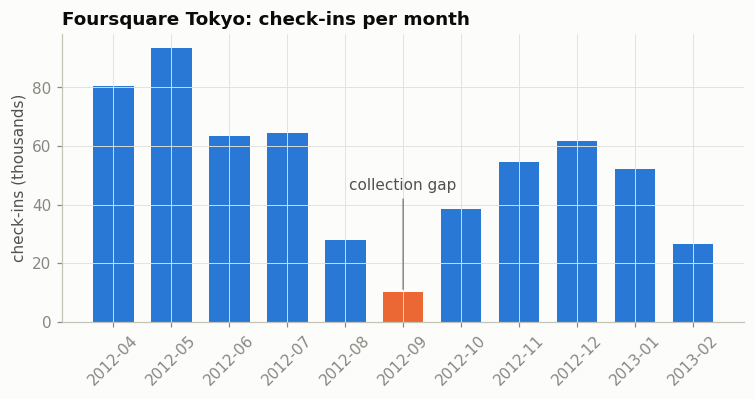

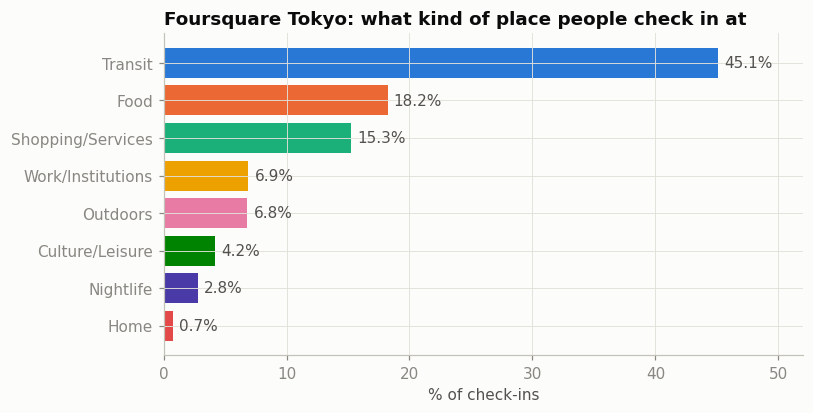

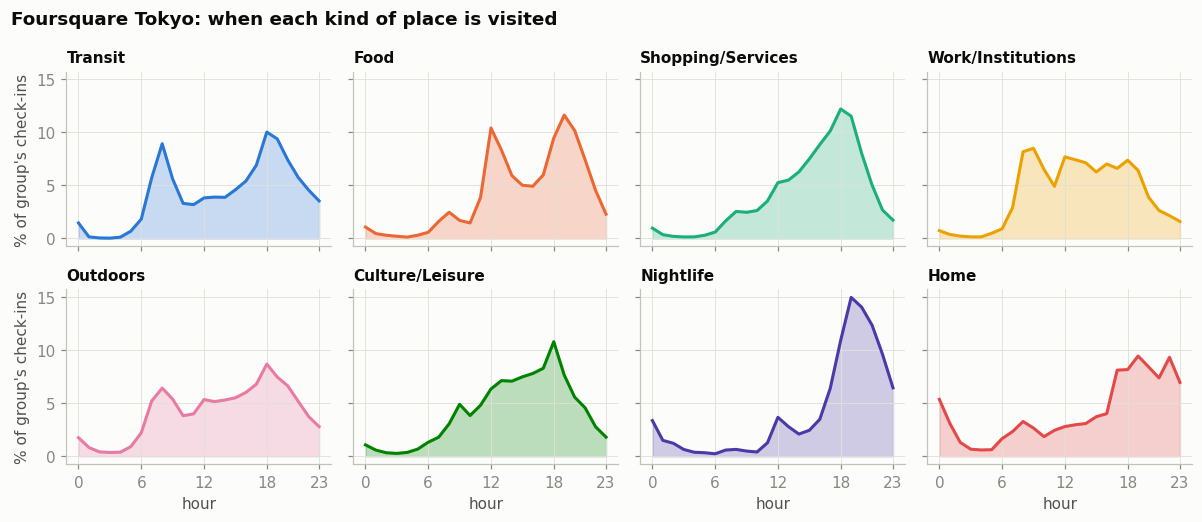

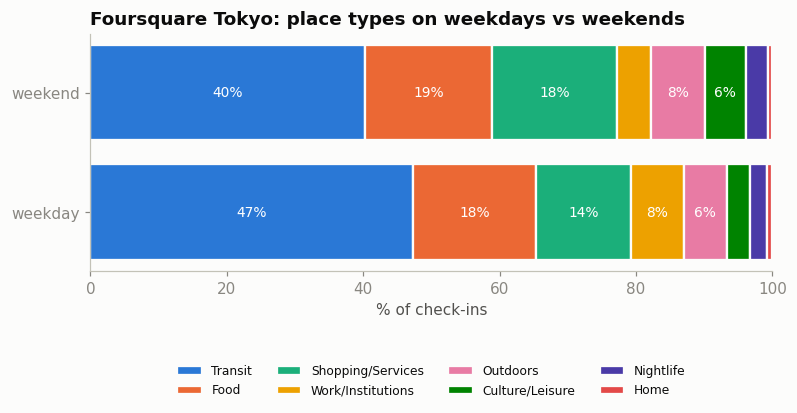

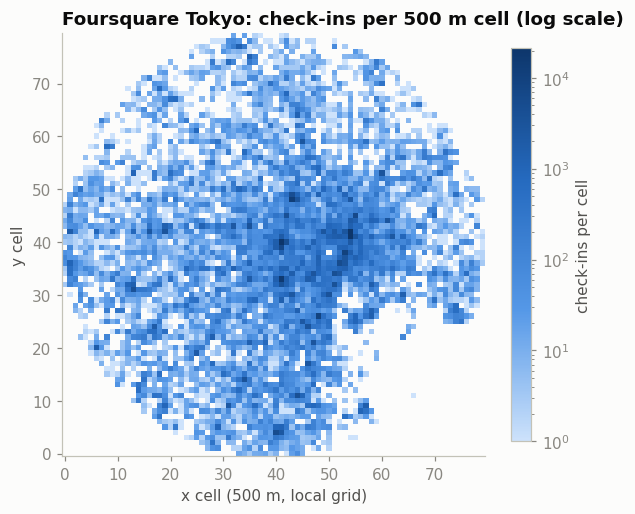

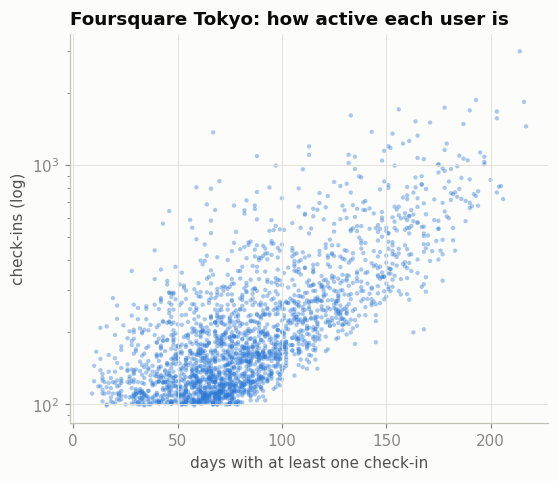

In [19]:
GROUPS = ["Transit","Food","Shopping/Services","Work/Institutions","Outdoors","Culture/Leisure","Nightlife","Home"]
GCOL = dict(zip(GROUPS, C))

# F10 check-ins per month with the collection gap
m = fs2.month.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8,3.4))
ax.bar(m.index, m.values/1000, color=[C[1] if k=="2012-09" else C[0] for k in m.index], width=0.7)
i = m.index.get_loc("2012-09")
ax.annotate("collection gap", xy=(i, m["2012-09"]/1000), xytext=(i, 45), ha="center", color="#52514e",
            arrowprops=dict(arrowstyle="-", color="#898781"))
ax.set(ylabel="check-ins (thousands)", title="Foursquare Tokyo: check-ins per month"); ax.tick_params(axis="x", rotation=45)
save(fig, "f10_fsq_checkins_per_month")

# F11 share of check-ins by coarse place type
g = fs2.group.value_counts(normalize=True).reindex(GROUPS)*100
fig, ax = plt.subplots(figsize=(7.5,3.8))
ax.barh(g.index[::-1], g.values[::-1], color=[GCOL[k] for k in g.index[::-1]])
for i, v in enumerate(g.values[::-1]): ax.text(v+0.5, i, f"{v:.1f}%", va="center", color="#52514e")
ax.set(xlabel="% of check-ins", title="Foursquare Tokyo: what kind of place people check in at", xlim=(0, 52))
save(fig, "f11_fsq_group_share")

# F12 hour-of-day profile per group (each group normalised to its own total)
fig, axes = plt.subplots(2, 4, figsize=(11,4.8), sharex=True, sharey=True)
for ax, gname in zip(axes.flat, GROUPS):
    h = fs2[fs2.group==gname].hour.value_counts(normalize=True).sort_index().reindex(range(24), fill_value=0)*100
    ax.fill_between(h.index, h.values, color=GCOL[gname], alpha=0.25); ax.plot(h.index, h.values, color=GCOL[gname], lw=2)
    ax.set_title(gname, fontsize=10); ax.set_xticks([0,6,12,18,23])
for ax in axes[1]: ax.set_xlabel("hour")
for ax in axes[:,0]: ax.set_ylabel("% of group's check-ins")
fig.suptitle("Foursquare Tokyo: when each kind of place is visited", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); save(fig, "f12_fsq_hour_by_group")

# F13 weekday vs weekend composition
wk = fs2.groupby(["weekend","group"]).size().unstack().reindex(columns=GROUPS).apply(lambda r: r/r.sum()*100, axis=1)
fig, ax = plt.subplots(figsize=(8,2.8))
for i, (lab, row) in enumerate([("weekday", wk.loc[False]), ("weekend", wk.loc[True])]):
    left = 0
    for gname in GROUPS:
        ax.barh(i, row[gname], left=left, color=GCOL[gname], edgecolor="#fcfcfb", lw=1.5, label=gname if i==0 else None)
        if row[gname] > 6: ax.text(left+row[gname]/2, i, f"{row[gname]:.0f}%", ha="center", va="center", color="white", fontsize=9)
        left += row[gname]
ax.set_yticks([0,1]); ax.set_yticklabels(["weekday","weekend"]); ax.set(xlim=(0,100), xlabel="% of check-ins", title="Foursquare Tokyo: place types on weekdays vs weekends")
ax.legend(frameon=False, ncol=4, fontsize=8, loc="upper center", bbox_to_anchor=(0.5,-0.35)); ax.grid(False)
save(fig, "f13_fsq_weekday_weekend")

# F14 check-in map on the 500 m grid
fg = np.zeros((80,80)); np.add.at(fg, (fs2.cy.values-1, fs2.cx.values-1), 1)
fig, ax = plt.subplots(figsize=(6.2,5.8))
im = ax.imshow(np.where(fg>0, fg, np.nan), origin="lower", cmap=BLUES, norm=LogNorm(vmin=1, vmax=fg.max()))
ax.grid(False); ax.set(xlabel="x cell (500 m, local grid)", ylabel="y cell", title="Foursquare Tokyo: check-ins per 500 m cell (log scale)")
fig.colorbar(im, ax=ax, shrink=0.8, label="check-ins per cell")
save(fig, "f14_fsq_checkin_map")

# F15 users: check-ins and active days
ud = fs2.groupby("user_id").agg(n=("venue_id","size"), days=("local", lambda s: s.dt.date.nunique()))
fig, ax = plt.subplots(figsize=(5.6,4.6))
ax.scatter(ud.days, ud.n, s=8, alpha=0.4, color=C[0], edgecolor="none"); ax.set_yscale("log")
ax.set(xlabel="days with at least one check-in", ylabel="check-ins (log)", title="Foursquare Tokyo: how active each user is")
save(fig, "f15_fsq_user_activity")
plt.show()

## What the Foursquare figures show

Check-in volume is uneven over time (f10), with the September 2012 collection gap. Transit dominates (45%, f11) and shrinks on weekends while shopping, outdoors and culture grow (f13). The hour profiles per place type (f12) are the key result for the place-type classifier: transit has two commute peaks, food has lunch and dinner, shopping climbs to an evening peak, nightlife is a single spike after 18:00 and home rises at night, so time of day alone already separates kinds of place. The map (f14) shows a circular extent: check-ins were collected within a fixed radius of a centre, one more artefact of how the data were gathered. Users are all active (100+ check-ins by construction of the dataset), with activity spread over 10 to 220 days (f15).

In [20]:
# raw vs cleaned snapshots as images
def table_png(df, name, title, width=11):
    fig, ax = plt.subplots(figsize=(width, 0.4*len(df)+0.9)); ax.axis("off"); ax.grid(False)
    tb = ax.table(cellText=df.astype(str).values, colLabels=list(df.columns), loc="center", cellLoc="left")
    tb.auto_set_font_size(False); tb.set_fontsize(8.5); tb.scale(1, 1.25)
    for (r, c), cell in tb.get_celld().items():
        cell.set_edgecolor("#e1e0d9")
        if r == 0: cell.set_facecolor("#e8f0fb"); cell.set_text_props(weight="bold")
    ax.set_title(title, loc="left", fontweight="bold"); save(fig, name); plt.close(fig)

raw_yj = pd.read_csv(RAW / "yjmob100k-dataset2.csv.gz", nrows=8)
table_png(raw_yj, "t01_yjmob_raw", "YJMob100K dataset 2, raw (first 8 rows)", 5)
table_png(an[an.uid==1].head(8).drop(columns=["slot"]), "t02_yjmob_clean", "YJMob analysis table, cleaned (person 1, first 8 rows)", 13)
table_png(poi.head(8), "t03_poi_raw", "YJMob POI table, raw (first 8 rows)", 5)
table_png(cells.reset_index().head(8)[["x","y","cat1","cat2","cat3","cat59","cat81","has_poi","poi_total"]], "t04_poi_clean", "Cell table, cleaned (8 rows, 9 of 87 columns)", 9)
raw_fs = pd.read_csv(zf.open(tky_name), sep="\t", header=None, names=cols, encoding="latin-1", nrows=6)
table_png(raw_fs, "t05_fsq_raw", "Foursquare TKY, raw (first 6 rows)", 14)
table_png(fs2.head(6)[["user_id","venue_cat_name","group","local","cx","cy","hour","weekday","weekend","tz_flag"]], "t06_fsq_clean", "Foursquare TKY, cleaned (first 6 rows, 10 of 15 columns)", 13)

print("\nfiles in figures/:", len(list(FIG.glob("*.png"))))
print("\nprocessed files:")
for p in sorted((ROOT/"data/processed").glob("*")): print(f"  {p.name:40s} {p.stat().st_size/1e6:8.1f} MB")

saved t01_yjmob_raw
saved t02_yjmob_clean
saved t03_poi_raw
saved t04_poi_clean
saved t05_fsq_raw
saved t06_fsq_clean

files in figures/: 21

processed files:
  cell_table.parquet                            0.5 MB
  foursquare_category_groups.csv                0.0 MB
  foursquare_tky.parquet                       14.6 MB
  person_table.parquet                          0.4 MB
  yjmob_analysis.parquet                      161.2 MB


In [21]:
# write the reproducible prep script
import shutil; shutil.copy(ROOT / "data/processed/foursquare_category_groups.csv", ROOT / "code/foursquare_category_groups.csv")

PosixPath('/projects/ancz7294/yjmob/code/foursquare_category_groups.csv')

In [22]:
%%writefile /projects/ancz7294/yjmob/code/prep.py
"""Data preparation for 'Agent reliability under disruption'.
Derived from notebooks/01_first_look.ipynb (2026-09-17). Reproduces the processed tables from the raw files.
Decisions (see notebook): nothing is deleted from YJMob; records are flagged. Windows fit 0-44 / val 45-59 / fb 60-66 / tgt 67-74.
Weekend-like phases {0, 6}. Split 70/30 by uid, seed 20260917. Eligibility: >= 20 adjacent pairs in every window.
Flags: adjacent (gap 1 slot), big_jump (> 100 cells in 30 min), flicker_mid (middle of a one-cell A-B-A). Foursquare: exact
duplicates dropped, JST local time for all rows (tz_flag), names normalised, 500 m local grid, coarse groups from the reviewed csv.
Usage: python prep.py [--root /projects/ancz7294/yjmob]
"""
import argparse, hashlib, zipfile, json, time
from pathlib import Path
import numpy as np, pandas as pd

SEED, N_PEOPLE = 20260917, 25000
MD5 = {"yjmob100k-dataset2.csv.gz": "ec769fafa7a746caa3d48d2844b9735c", "cell_POIcat.csv.gz": "93af4bb0b417cd20e95fdc1d8f7b459f",
       "POI_datacategories.csv": "fd024e10c1d1dd91356d010413ace390", "foursquare/dataset_tsmc2014.zip": "a9534dc06f0495b36f216017d2f47701"}

def md5(p):
    h = hashlib.md5()
    with open(p, "rb") as f:
        for b in iter(lambda: f.read(1 << 22), b""): h.update(b)
    return h.hexdigest()

def prep_yjmob(raw, out, log):
    yj = pd.read_csv(raw / "yjmob100k-dataset2.csv.gz", engine="pyarrow",
                     dtype={"uid": "int32", "d": "int16", "t": "int16", "x": "int16", "y": "int16"})
    assert yj.isna().sum().sum() == 0 and not yj.duplicated(["uid", "d", "t"]).any()
    key = yj.uid.astype("int64") * 10000 + yj.d.astype("int64") * 100 + yj.t
    assert key.is_monotonic_increasing, "raw file expected sorted by uid, d, t"
    log["yjmob_rows"] = len(yj)

    same = yj.uid.values[1:] == yj.uid.values[:-1]
    gap = (yj.d.values[1:].astype("int32") - yj.d.values[:-1]) * 48 + (yj.t.values[1:].astype("int32") - yj.t.values[:-1])
    x, y = yj.x.values.astype("int32"), yj.y.values.astype("int32")
    cheb = np.maximum(np.abs(x[1:] - x[:-1]), np.abs(y[1:] - y[:-1]))
    g = np.r_[gap, 0]
    trip = (yj.uid.values[2:] == yj.uid.values[:-2]) & (g[:-2] == 1) & (g[1:-1] == 1)
    back = (x[2:] == x[:-2]) & (y[2:] == y[:-2]) & ((x[1:-1] != x[:-2]) | (y[1:-1] != y[:-2]))
    one = np.maximum(np.abs(x[1:-1] - x[:-2]), np.abs(y[1:-1] - y[:-2])) == 1

    an = yj.copy()
    an["phase"] = (an.d % 7).astype("int8"); an["weekend"] = an.phase.isin([0, 6])
    an["window"] = pd.cut(an.d, bins=[-1, 44, 59, 66, 74], labels=["fit", "val", "fb", "tgt"]).astype("category")
    an["slot"] = (an.d.astype("int32") * 48 + an.t).astype("int32")
    prev_same = np.r_[False, same]
    an["gap_prev"] = np.where(prev_same, np.r_[0, gap], -1).astype("int16")
    an["step_prev"] = np.where(prev_same, np.r_[0, cheb], -1).astype("int16")
    an["adjacent"] = an.gap_prev == 1
    an["big_jump"] = an.adjacent & (an.step_prev > 100)
    fl = np.zeros(len(an), bool); fl[1:-1] = trip & back & one; an["flicker_mid"] = fl

    # person table, split, eligibility
    adj = an[an.adjacent]
    ppw = adj.groupby(["uid", "window"], observed=False).size().unstack(fill_value=0)
    ppw.columns = ["fit_0_44", "val_45_59", "fb_60_66", "tgt_67_74"]
    prof = an.groupby("uid").agg(rows=("d", "size"), days=("d", "nunique"))
    prof["ncells"] = an.drop_duplicates(["uid", "x", "y"]).groupby("uid").size()
    prof["big_jumps"] = an.groupby("uid").big_jump.sum().astype("int64")
    rng = np.random.default_rng(SEED)
    dev = np.zeros(N_PEOPLE, bool); dev[rng.choice(N_PEOPLE, size=int(0.7 * N_PEOPLE), replace=False)] = True
    prof = prof.join(ppw)
    prof["split"] = np.where(dev[prof.index], "dev", "eval")
    prof["eligible"] = (ppw >= 20).all(axis=1)
    prof.to_parquet(out / "person_table.parquet")
    log["eligible_dev_share"] = float(prof.eligible[prof.split == "dev"].mean())

    an = an.join(prof[["split", "eligible"]], on="uid"); an["split"] = an.split.astype("category")
    an.to_parquet(out / "yjmob_analysis.parquet", index=False)
    log["flag_shares"] = {c: float(an[c].mean()) for c in ["adjacent", "big_jump", "flicker_mid"]}

    # cell table
    poi = pd.read_csv(raw / "cell_POIcat.csv.gz")
    wide = poi.pivot_table(index=["x", "y"], columns="POIcategory", values="POI_count", fill_value=0, aggfunc="sum")
    wide.columns = [f"cat{c}" for c in wide.columns]
    cells = yj[["x", "y"]].drop_duplicates().set_index(["x", "y"]).join(wide, how="left")
    cells["has_poi"] = cells["cat1"].notna()
    cells = cells.fillna(0).astype({c: "int32" for c in wide.columns})
    cells["poi_total"] = cells[wide.columns].sum(axis=1)
    cells.to_parquet(out / "cell_table.parquet")
    log["cells"] = len(cells)

def prep_foursquare(raw, out, code, log):
    zf = zipfile.ZipFile(raw / "foursquare/dataset_tsmc2014.zip")
    name = [n for n in zf.namelist() if "TKY" in n and n.endswith(".txt")][0]
    cols = ["user_id", "venue_id", "venue_cat_id", "venue_cat_name", "lat", "lon", "tz_offset", "utc_time"]
    fs = pd.read_csv(zf.open(name), sep="\t", header=None, names=cols, encoding="latin-1")
    log["fsq_raw_rows"] = len(fs)
    fs = fs.drop_duplicates().copy()
    fs["tz_flag"] = fs.tz_offset != 540
    utc = pd.to_datetime(fs.utc_time, format="%a %b %d %H:%M:%S %z %Y", utc=True)
    fs["local"] = (utc + pd.Timedelta(minutes=540)).dt.tz_localize(None)
    fs["venue_cat_name"] = fs.venue_cat_name.str.replace(r"\s+", " ", regex=True).str.strip()
    lat0, lon0 = fs.lat.min(), fs.lon.min()
    kx = 111.32 * np.cos(np.deg2rad(fs.lat.mean())); ky = 111.32
    fs["cx"] = ((fs.lon - lon0) * kx / 0.5).astype("int16") + 1
    fs["cy"] = ((fs.lat - lat0) * ky / 0.5).astype("int16") + 1
    fs["hour"] = fs.local.dt.hour.astype("int8"); fs["weekday"] = fs.local.dt.weekday.astype("int8")
    fs["weekend"] = fs.weekday >= 5; fs["month"] = fs.local.dt.to_period("M").astype(str)
    cmap = pd.read_csv(code / "foursquare_category_groups.csv").set_index("venue_cat_name").group
    missing = set(fs.venue_cat_name) - set(cmap.index)
    assert not missing, f"names without a group: {missing}"
    fs["group"] = fs.venue_cat_name.map(cmap)
    keep = ["user_id", "venue_id", "venue_cat_id", "venue_cat_name", "lat", "lon", "local", "tz_flag", "cx", "cy", "hour", "weekday", "weekend", "month", "group"]
    fs = fs.sort_values(["user_id", "local"]).reset_index(drop=True)[keep]
    fs.to_parquet(out / "foursquare_tky.parquet", index=False)
    log["fsq_clean_rows"] = len(fs)

if __name__ == "__main__":
    ap = argparse.ArgumentParser(); ap.add_argument("--root", default="/projects/ancz7294/yjmob"); a = ap.parse_args()
    root = Path(a.root); raw, out, code = root / "data/raw", root / "data/processed", root / "code"
    out.mkdir(parents=True, exist_ok=True); t0 = time.time(); log = {}
    for rel, want in MD5.items():
        got = md5(raw / rel); assert got == want, f"md5 mismatch for {rel}: {got}"
    prep_yjmob(raw, out, log); prep_foursquare(raw, out, code, log)
    log["seconds"] = round(time.time() - t0, 1)
    (root / "logs/prep_log.json").write_text(json.dumps(log, indent=2)); print(json.dumps(log, indent=2))

Writing /projects/ancz7294/yjmob/code/prep.py


In [25]:
# test of reproductability
import subprocess
r = subprocess.run([sys.executable, str(ROOT / "code/prep.py")], capture_output=True, text=True)
print(r.stdout[-2000:], r.stderr[-2000:])
chk = {"yjmob_analysis.parquet": an.drop(columns=[]), "person_table.parquet": prof, "cell_table.parquet": cells,
       "foursquare_tky.parquet": fs2.sort_values(["user_id","local"]).reset_index(drop=True)}
for fname, ref in chk.items():
    new = pd.read_parquet(ROOT / "data/processed" / fname)
    common = [c for c in ref.columns if c in new.columns]
    eq = new[common].reset_index(drop=True).equals(ref[common].reset_index(drop=True))
    print(f"{fname:28s} shape {new.shape}  columns match {sorted(common)==sorted(new.columns)}  values equal {eq}")

{
  "yjmob_rows": 29389749,
  "eligible_dev_share": 0.9631428571428572,
  "flag_shares": {
    "adjacent": 0.6982727208728459,
    "big_jump": 0.0003884007311528928,
    "flicker_mid": 0.03473282470020414
  },
  "cells": 30277,
  "fsq_raw_rows": 573703,
  "fsq_clean_rows": 573126,
  "seconds": 29.8
}
 
yjmob_analysis.parquet       shape (29389749, 16)  columns match True  values equal False
person_table.parquet         shape (25000, 10)  columns match True  values equal False
cell_table.parquet           shape (30277, 87)  columns match True  values equal True
foursquare_tky.parquet       shape (573126, 15)  columns match True  values equal True


In [24]:
# quick check if tables differ
for fname, ref in [("yjmob_analysis.parquet", an), ("person_table.parquet", prof)]:
    new = pd.read_parquet(ROOT / "data/processed" / fname)
    ref = ref.reset_index(drop=(fname=="yjmob_analysis.parquet")); new = new.reset_index(drop=(fname=="yjmob_analysis.parquet"))
    for c in ref.columns:
        a, b = ref[c], new[c]
        same_vals = (a.astype(str).values == b.astype(str).values).all()
        if not same_vals or a.dtype != b.dtype:
            print(f"{fname} {c:12s} dtype {a.dtype} vs {b.dtype}  values equal {same_vals}")

yjmob_analysis.parquet eligible     dtype bool vs bool  values equal False
person_table.parquet uid          dtype int64 vs int32  values equal True
person_table.parquet fit_0_44     dtype int64 vs int64  values equal False
person_table.parquet val_45_59    dtype int64 vs int64  values equal False
person_table.parquet fb_60_66     dtype int64 vs int64  values equal False
person_table.parquet tgt_67_74    dtype int64 vs int64  values equal False
person_table.parquet eligible     dtype bool vs bool  values equal False


## Verified

The notebook counted pairs by the window of the first record; the final prep script (code/prep.py) counts them by the window of the target record, which is what the evaluation scores. The two differ only at window boundaries and the processed tables on disk follow the script.

## Outputs

Processed tables in data/processed: yjmob_analysis.parquet (29.4M rows, 16 columns), person_table.parquet (25,000), cell_table.parquet (30,277 cells x 85 categories + flags), foursquare_tky.parquet (573,126 check-ins, 15 columns), foursquare_category_groups.csv (247 names to 8 groups). Figures in figures/: 15 charts (f01-f15) and 6 raw/clean table snapshots (t01-t06). Script code/prep.py reproduces the tables from the raw files (34 s) with md5 checks on the inputs.
